# KMeans Model - CIS 2450 Final Project
K-Means on Joined OpenAlex + Semantic Scholar Data

This notebook joins `openalex_papers` with `semanticscholar_papers`, filters out rows with missing abstracts or TLDRs, vectorizes the text, and clusters the papers with K-Means.

## Setup

In [ ]:
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from scipy.sparse import csr_matrix, hstack
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Load Data

In [ ]:
# Load the joined dataset and keep only rows with a stored abstract vector and TLDR text
DB_PATH = Path("papers.db")
if not DB_PATH.exists():
    DB_PATH = Path("../papers.db")

JOINED_QUERY = """
SELECT
    o.openalex_id,
    o.doi,
    o.doi_normalized,
    o.title,
    o.publication_year,
    o.cited_by_count,
    o.author_count,
    o.primary_topic,
    o.primary_subfield,
    o.primary_field,
    o.primary_domain,
    s.abstract_text,
    s.abstract_tfidf_vector,
    s.tldr_text
FROM openalex_papers AS o
JOIN semanticscholar_papers AS s
    ON o.doi_normalized = s.doi_normalized
WHERE s.abstract_text IS NOT NULL
  AND TRIM(s.abstract_text) <> ''
  AND s.abstract_tfidf_vector IS NOT NULL
  AND TRIM(s.abstract_tfidf_vector) <> ''
  AND s.tldr_text IS NOT NULL
  AND TRIM(s.tldr_text) <> ''
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pl.read_database(query=JOINED_QUERY, connection=conn)

print(f"Joined rows with abstract vector + TLDR: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Joined rows with abstract vector + TLDR: 73659
Columns: 14


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,abstract_text,abstract_tfidf_vector,tldr_text
str,str,str,str,i64,i64,i64,str,str,str,str,str,str,str
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""In the realm of deep learning,…","""{""dimension"": 2000, ""indices"":…","""It is revealed that current sp…"
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""The Model Context Protocol (MC…","""{""dimension"": 2000, ""indices"":…","""A comprehensive threat taxonom…"
"""https://openalex.org/W44007028…","""https://doi.org/10.1109/tnnls.…","""10.1109/tnnls.2025.3646122""","""Graph Transformers: A Survey""",2026,16,7,"""Advanced Graph Neural Networks""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Graph transformers are a recen…","""{""dimension"": 2000, ""indices"":…","""This survey provides an in-dep…"
"""https://openalex.org/W43969140…","""https://doi.org/10.1007/s11263…","""10.1007/s11263-025-02646-6""","""Deep Learning-Based Object Pos…",2026,14,10,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""","""Computer Science""","""Physical Sciences""","""Object pose estimation is a fu…","""{""dimension"": 2000, ""indices"":…","""This survey discusses the rece…"
"""https://openalex.org/W44043502…","""https://doi.org/10.1038/s41567…","""10.1038/s41567-025-03144-9""","""Dynamical simulations of many-…",2026,9,19,"""Neural Networks and Reservoir …","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Quantum circuits with local un…","""{""dimension"": 2000, ""indices"":…","""This work studies dual-unitary…"


In [ ]:
# Split the rows once so every learned transform is fit on train only.
SPLIT_SEED = 42
CATEGORICAL_COLUMNS = [
    "primary_topic",
    "primary_subfield",
    "primary_field",
    "primary_domain",
]

train_indices, temp_indices = train_test_split(
    list(range(df.height)),
    test_size=0.30,
    random_state=SPLIT_SEED,
    shuffle=True,
)
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SPLIT_SEED,
    shuffle=True,
)

train_df = df[train_indices]
val_df = df[val_indices]
test_df = df[test_indices]

pl.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [train_df.height, val_df.height, test_df.height],
})


split,rows
str,i64
"""train""",51561
"""validation""",11049
"""test""",11049


In [ ]:
# Keep the structured preprocessing small and reusable.
def prepare_structured_frame(frame):
    return frame.select([
        pl.col("publication_year").cast(pl.Float64),
        pl.col("cited_by_count").fill_null(0).clip(lower_bound=0).log1p(),
        pl.col("author_count").fill_null(0).clip(lower_bound=0).log1p(),
        pl.col("primary_topic").fill_null("Unknown"),
        pl.col("primary_subfield").fill_null("Unknown"),
        pl.col("primary_field").fill_null("Unknown"),
        pl.col("primary_domain").fill_null("Unknown"),
    ])

def encode_structured(frame, reference_columns=None):
    encoded = prepare_structured_frame(frame).to_dummies(columns=CATEGORICAL_COLUMNS)
    if reference_columns is None:
        return encoded, encoded.columns

    missing_columns = [column for column in reference_columns if column not in encoded.columns]
    if missing_columns:
        encoded = encoded.with_columns([pl.lit(0).alias(column) for column in missing_columns])
    return encoded.select(reference_columns)


In [ ]:
# Fit the structured scaler on train, then reuse it on validation and test.
train_structured_encoded, structured_feature_columns = encode_structured(train_df)
val_structured_encoded = encode_structured(val_df, structured_feature_columns)
test_structured_encoded = encode_structured(test_df, structured_feature_columns)

structured_scaler = StandardScaler()
structured_train_matrix = csr_matrix(structured_scaler.fit_transform(train_structured_encoded.to_numpy()))
structured_val_matrix = csr_matrix(structured_scaler.transform(val_structured_encoded.to_numpy()))
structured_test_matrix = csr_matrix(structured_scaler.transform(test_structured_encoded.to_numpy()))

pl.DataFrame({
    "split": ["train", "validation", "test"],
    "structured_shape": [
        str(structured_train_matrix.shape),
        str(structured_val_matrix.shape),
        str(structured_test_matrix.shape),
    ],
})


split,structured_shape
str,str
"""train""","""(51561, 311)"""
"""validation""","""(11049, 311)"""
"""test""","""(11049, 311)"""


In [ ]:
# Convert stored abstract TF-IDF JSON blobs into sparse matrices.
def stored_tfidf_vectors_to_csr(vector_jsons):
    data = []
    indices = []
    indptr = [0]
    dimension = None

    for vector_json in vector_jsons:
        vector = json.loads(vector_json)
        vector_dimension = vector["dimension"]
        if dimension is None:
            dimension = vector_dimension
        elif dimension != vector_dimension:
            raise ValueError("Stored abstract TF-IDF vectors have inconsistent dimensions")

        indices.extend(vector["indices"])
        data.extend(vector["values"])
        indptr.append(len(indices))

    return csr_matrix((data, indices, indptr), shape=(len(vector_jsons), dimension or 0))


In [ ]:
# Fit the TLDR vectorizer on train only; the abstract vectors are already stored.
tldr_vectorizer = TfidfVectorizer(stop_words="english", max_features=750, min_df=3)

abstract_train_matrix = stored_tfidf_vectors_to_csr(train_df["abstract_tfidf_vector"].to_list())
abstract_val_matrix = stored_tfidf_vectors_to_csr(val_df["abstract_tfidf_vector"].to_list())
abstract_test_matrix = stored_tfidf_vectors_to_csr(test_df["abstract_tfidf_vector"].to_list())

tldr_train_matrix = tldr_vectorizer.fit_transform(train_df["tldr_text"].to_list())
tldr_val_matrix = tldr_vectorizer.transform(val_df["tldr_text"].to_list())
tldr_test_matrix = tldr_vectorizer.transform(test_df["tldr_text"].to_list())

pl.DataFrame({
    "split": ["train", "validation", "test"],
    "abstract_shape": [
        str(abstract_train_matrix.shape),
        str(abstract_val_matrix.shape),
        str(abstract_test_matrix.shape),
    ],
    "tldr_shape": [
        str(tldr_train_matrix.shape),
        str(tldr_val_matrix.shape),
        str(tldr_test_matrix.shape),
    ],
})


split,abstract_shape,tldr_shape
str,str,str
"""train""","""(51561, 2000)""","""(51561, 750)"""
"""validation""","""(11049, 2000)""","""(11049, 750)"""
"""test""","""(11049, 2000)""","""(11049, 750)"""


In [ ]:
# Stack each split into the final feature matrix used by K-Means.
split_feature_matrices = {
    "train": hstack([structured_train_matrix, abstract_train_matrix, tldr_train_matrix], format="csr"),
    "validation": hstack([structured_val_matrix, abstract_val_matrix, tldr_val_matrix], format="csr"),
    "test": hstack([structured_test_matrix, abstract_test_matrix, tldr_test_matrix], format="csr"),
}

X_train = split_feature_matrices["train"]
X_val = split_feature_matrices["validation"]
X_test = split_feature_matrices["test"]
X = X_test

pl.DataFrame({
    "split": ["train", "validation", "test"],
    "feature_shape": [
        str(X_train.shape),
        str(X_val.shape),
        str(X_test.shape),
    ],
})


split,feature_shape
str,str
"""train""","""(51561, 3061)"""
"""validation""","""(11049, 3061)"""
"""test""","""(11049, 3061)"""


## Hyperparameter Tuning

In [ ]:
# Small helper for validation scoring.
K_VALUES = range(2, 11)

def sampled_silhouette(matrix, labels, sample_size=2000):
    label_set = {int(label) for label in labels}
    if matrix.shape[0] < 2 or len(label_set) < 2:
        return float("-inf")
    return silhouette_score(
        matrix,
        labels,
        sample_size=min(sample_size, matrix.shape[0]),
        random_state=SPLIT_SEED,
    )

# Each later cell assumes these are available.
results_df = None
best_k = None
best_val_score = None


In [ ]:
# Fit each candidate on train, then score it on validation.
results = []
for k in K_VALUES:
    model = KMeans(n_clusters=k, random_state=SPLIT_SEED, n_init=10)
    model.fit(X_train)
    val_labels = model.predict(X_val)
    results.append({
        "k": k,
        "train_inertia": float(model.inertia_),
        "val_silhouette": sampled_silhouette(X_val, val_labels),
    })

results_df = pl.DataFrame(results).sort("k")
best_row = results_df.sort("val_silhouette", descending=True).row(0, named=True)
best_k = int(best_row["k"])
best_val_score = float(best_row["val_silhouette"])

print(f"Selected k={best_k} using validation silhouette={best_val_score:.4f}")
results_df.sort("val_silhouette", descending=True)

Selected k=2 using validation silhouette=0.0231


k,train_inertia,val_silhouette
i64,f64,f64
2,1.5925e7,0.023061
3,1.5858e7,0.011193
5,1.5750e7,-0.047855
7,1.5563e7,-0.107751
4,1.5794e7,-0.113934
10,1.5343e7,-0.145866
6,1.5660e7,-0.179527
9,1.5415e7,-0.180321
8,1.5550e7,-0.201121


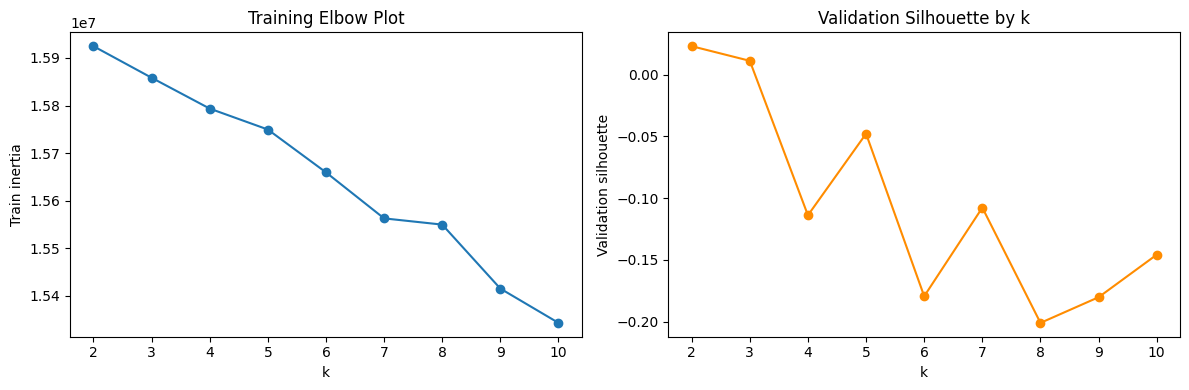

In [ ]:
# Plot training inertia and validation silhouette across k values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df["k"].to_list(), results_df["train_inertia"].to_list(), marker="o")
axes[0].set_title("Training Elbow Plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Train inertia")

axes[1].plot(
    results_df["k"].to_list(),
    results_df["val_silhouette"].to_list(),
    marker="o",
    color="darkorange",
)
axes[1].set_title("Validation Silhouette by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Validation silhouette")

plt.tight_layout()
plt.show()

## Fit K-Means

In [ ]:
# Fit the final model with the best validation k.
kmeans_model = KMeans(n_clusters=best_k, random_state=SPLIT_SEED, n_init=10)
train_clusters = kmeans_model.fit_predict(X_train)
val_clusters = kmeans_model.predict(X_val)
test_clusters = kmeans_model.predict(X_test)
clusters = test_clusters

pl.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
})

split,rows
str,i64
"""train""",51561
"""validation""",11049
"""test""",11049


In [ ]:
# Add cluster labels back to the held-out test dataframe
df_clustered = test_df.with_columns(pl.Series("cluster", test_clusters))

df_clustered.select([
    "title",
    "publication_year",
    "primary_topic",
    "primary_subfield",
    "cluster",
]).head(10)

title,publication_year,primary_topic,primary_subfield,cluster
str,i64,str,str,i32
"""Detecting LLM-generated peer r…",2025,"""Hate Speech and Cyberbullying …","""Artificial Intelligence""",1
"""BEYOND CHAT: A FRAMEWORK FOR L…",2025,"""Context-Aware Activity Recogni…","""Computer Vision and Pattern Re…",1
"""Reliability and Validity Testi…",2025,"""Education and Learning Interve…","""Information Systems""",1
"""Hybrid Deep Learning Framework…",2025,"""Advanced Vision and Imaging""","""Computer Vision and Pattern Re…",1
"""An Analysis of the Application…",2025,"""Educational Technology and Ped…","""Artificial Intelligence""",1
"""Leveraging Generative AI for F…",2025,"""Imbalanced Data Classification…","""Artificial Intelligence""",1
"""Who is Helping Whom? Student C…",2025,"""Online Learning and Analytics""","""Computer Science Applications""",0
"""Proof-of-Friendship Consensus …",2025,"""Blockchain Technology Applicat…","""Information Systems""",1
"""A Phrase Fill-in-Blank Problem…",2025,"""Software Testing and Debugging…","""Software""",1


## Predict nearby papers from a given paper

Use the fitted K-Means model to predict the selected paper's cluster, then rank held-out test papers inside that cluster by cosine similarity in the same combined feature space used for clustering.


In [ ]:
# These columns are accepted when resolving a paper query.
PAPER_LOOKUP_COLUMNS = [
    "title",
    "doi",
    "doi_normalized",
    "openalex_id",
]

In [ ]:
def find_paper_index(paper, papers_df=df_clustered):
    """Return the row index for a paper given a row number, DOI, OpenAlex ID, or title text."""
    if isinstance(paper, int):
        if 0 <= paper < papers_df.height:
            return paper
        raise ValueError(f"Paper row index {paper} is outside 0..{papers_df.height - 1}")

    query = str(paper).strip().lower()
    if not query:
        raise ValueError("Please provide a non-empty paper title, DOI, OpenAlex ID, or row index.")

    records = papers_df.select(PAPER_LOOKUP_COLUMNS).to_dicts()

    # Prefer exact identifier and exact title matches.
    for idx, record in enumerate(records):
        for column in PAPER_LOOKUP_COLUMNS:
            value = record.get(column)
            if value is not None and str(value).strip().lower() == query:
                return idx

    # Fall back to a title substring search for notebook demos.
    title_matches = [
        idx
        for idx, record in enumerate(records)
        if record.get("title") is not None and query in str(record["title"]).lower()
    ]
    if len(title_matches) == 1:
        return title_matches[0]
    if len(title_matches) > 1:
        matches = papers_df[title_matches].select(["title", "doi_normalized", "publication_year"])
        raise ValueError(f"Found {len(title_matches)} title matches. Use a row index or DOI to disambiguate:\n{matches}")

    raise ValueError(f"No paper found for: {paper}")

In [ ]:
def predict_nearby_papers(paper, n=10, same_cluster_only=True, include_query=False):
    """Find nearby papers for an existing paper in the modeled dataset."""
    query_idx = find_paper_index(paper)
    query_vector = X[query_idx]
    predicted_cluster = int(kmeans_model.predict(query_vector)[0])

    if same_cluster_only:
        candidate_indices = [idx for idx, cluster in enumerate(clusters) if int(cluster) == predicted_cluster]
    else:
        candidate_indices = list(range(X.shape[0]))

    similarities = cosine_similarity(query_vector, X[candidate_indices]).ravel()
    ranked = sorted(zip(candidate_indices, similarities), key=lambda item: item[1], reverse=True)

    if not include_query:
        ranked = [(idx, score) for idx, score in ranked if idx != query_idx]

    result_indices = [idx for idx, _ in ranked[:n]]
    result_scores = [float(score) for _, score in ranked[:n]]
    if not result_indices:
        return pl.DataFrame()

    return (
        df_clustered[result_indices]
        .with_columns(pl.Series("similarity_to_query", result_scores))
        .select([
            "similarity_to_query",
            "cluster",
            "title",
            "publication_year",
            "primary_topic",
            "primary_subfield",
            "doi",
            "openalex_id",
        ])
    )


In [ ]:
# Example query on the held-out test set.
example_paper = df_clustered[0, "title"]
print(f"Query paper: {example_paper}")
predict_nearby_papers(example_paper, n=5)


Query paper: Detecting LLM-generated peer reviews


similarity_to_query,cluster,title,publication_year,primary_topic,primary_subfield,doi,openalex_id
f64,i32,str,i64,str,str,str,str
0.990828,1,"""The End of Trust and Safety?: …",2025,"""Hate Speech and Cyberbullying …","""Artificial Intelligence""","""https://doi.org/10.1145/370659…","""https://openalex.org/W44097362…"
0.990757,1,"""Multi-modal Twitter Data Analy…",2025,"""Hate Speech and Cyberbullying …","""Artificial Intelligence""","""https://doi.org/10.1145/371307…","""https://openalex.org/W44066865…"
0.990441,1,"""<i>GOAT-Bench</i> : Safety Ins…",2025,"""Hate Speech and Cyberbullying …","""Artificial Intelligence""","""https://doi.org/10.1145/372923…","""https://openalex.org/W44093490…"
0.990155,1,"""Metalinguist: enhancing hate s…",2025,"""Hate Speech and Cyberbullying …","""Artificial Intelligence""","""https://doi.org/10.1007/s40747…","""https://openalex.org/W44080060…"
0.990019,1,"""Bilingual hate speech detectio…",2025,"""Hate Speech and Cyberbullying …","""Artificial Intelligence""","""https://doi.org/10.1186/s40537…","""https://openalex.org/W44072552…"


## Evaluate

In [ ]:
# Report held-out validation and test quality.
validation_score = sampled_silhouette(X_val, val_clusters)
test_score = sampled_silhouette(X_test, test_clusters)

print(f"Validation silhouette score: {validation_score:.4f}")
print(f"Test silhouette score: {test_score:.4f}")


Validation silhouette score: 0.0231
Test silhouette score: 0.0475


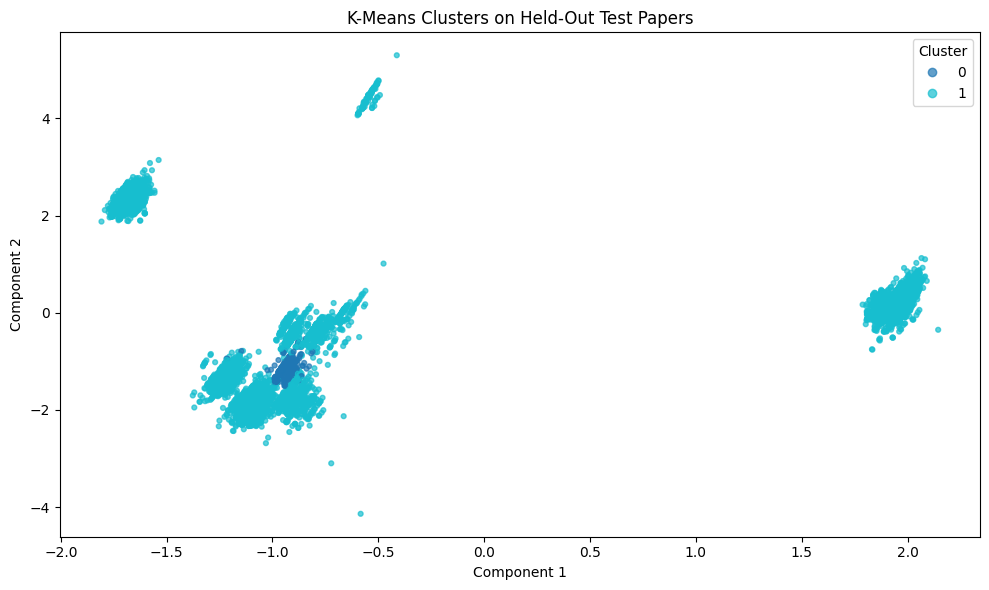

Explained variance ratio (fit on train): [0.00791256 0.00706899]


In [ ]:
# Fit the projection on train and visualize the held-out test set.
svd = TruncatedSVD(n_components=2, random_state=SPLIT_SEED)
svd.fit(X_train)
X_2d = svd.transform(X_test)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=clusters,
    cmap="tab10",
    s=12,
    alpha=0.7,
)
plt.title("K-Means Clusters on Held-Out Test Papers")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance ratio (fit on train):", svd.explained_variance_ratio_)


### Comments On Performance

The model is now tuned with a proper train/validation/test split, but the held-out silhouette scores may still show that K-Means is a weak fit for this feature space. If the validation and test scores remain low or negative after rerunning the notebook, the issue is probably the representation itself rather than overfitting the choice of k. The TLDR and abstract vectors may still be creating a curse-of-dimensionality problem, so the next step would be trying a different text representation, stronger dimensionality reduction, or a different clustering method altogether.